# Week 9 Exercises

### Ex 9.1

In [14]:
import numpy as np
import sys
sys.path.append('..')
from CV_functions import box3d, Pi, PiInv, projectpoints, CrossOp

F = np.array([[ 3.29311881e-07,  8.19396327e-07,  1.79162592e-03],
              [ 5.15532551e-07, -8.76915984e-07,  9.31426656e-05],
              [-1.29882755e-03,  1.51951700e-03, -1.10072682e+00]])

In [15]:
def Fest_8point(q1, q2):
    """
    Estimate fundamental matrix from >=8 correspondences (linear algorithm).
    q1, q2: (2,n) inhomogeneous points, q1 in image 1, q2 in image 2.
    Returns F (3,3) with ||flatten(F)|| = 1.
    """
    Q1 = q1  # (3,n)
    Q2 = q2  # (3,n)
    n = Q1.shape[1]

    B = (Q2.T[:, :, None] * Q1.T[:, None, :]).reshape(n, 9)  # each row = flatten(q2 q1^T)

    U, S, Vt = np.linalg.svd(B)
    F = Vt[-1].reshape(3, 3)
    return F

In [16]:
data = np.load('Fest_test.npy', allow_pickle=True).item()
q1, q2, Ftrue = data['q1'], data['q2'], data['Ftrue']

F = Fest_8point(q1, q2)
print(F)
Fn = F / np.linalg.norm(F)
Ftruen = Ftrue / np.linalg.norm(Ftrue)

print(np.allclose(Fn, Ftruen) or np.allclose(Fn, -Ftruen))

[[-3.07914555e-08  3.61883689e-06 -5.43583727e-04]
 [ 4.49876682e-06  2.24402705e-08 -1.51520136e-01]
 [-1.95223414e-03  1.48295604e-01  9.77264527e-01]]
True


### Ex 9.2

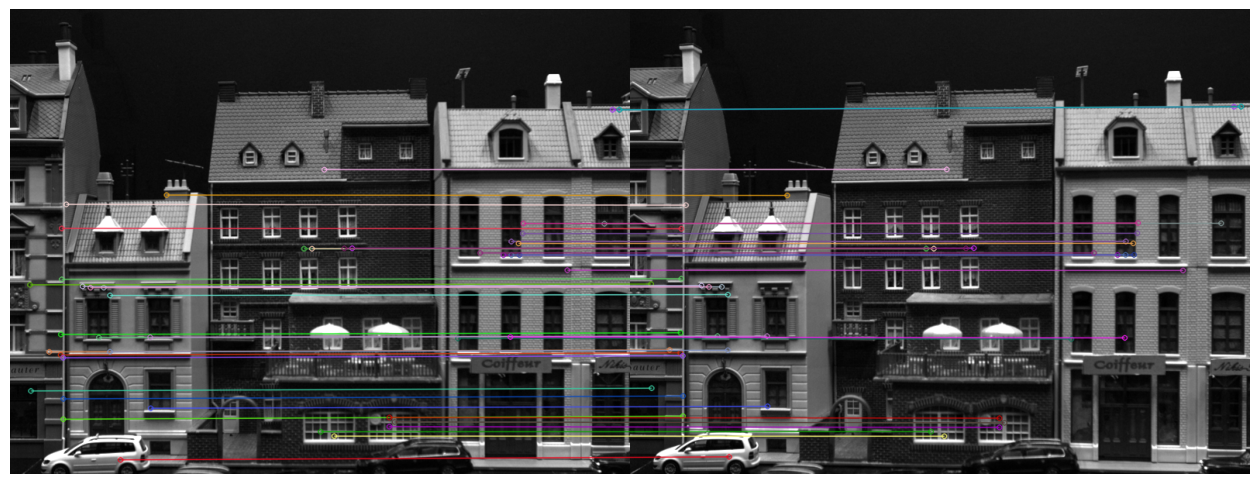

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

data = np.load('TwoImageData.npy', allow_pickle=True).item()
im1, im2 = data['im1'], data['im2']  # adjust keys if named differently — check data.keys()

sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(im1, None)
kp2, des2 = sift.detectAndCompute(im2, None)

bf = cv2.BFMatcher_create(crossCheck=True)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda m: m.distance)

img_matches = cv2.drawMatches(im1, kp1, im2, kp2, matches[:50], None,
                               flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(16, 8))
plt.imshow(img_matches)
plt.axis('off')
plt.show()

### Ex 9.3

In [22]:
def Fest_8point(q1, q2):
    Q1 = q1 if q1.shape[0] == 3 else PiInv(q1)
    Q2 = q2 if q2.shape[0] == 3 else PiInv(q2)
    n = Q1.shape[1]

    B = (Q2.T[:, :, None] * Q1.T[:, None, :]).reshape(n, 9)

    U, S, Vt = np.linalg.svd(B)
    F = Vt[-1].reshape(3, 3)
    return F

def SampsonsDistance(F, p1, p2):
    """
    Sampson's distance for each correspondence.
    p1, p2: (2,n) or (3,n) points, image 1 / image 2.
    Returns (n,) array of squared Sampson distances.
    """
    Q1 = p1 if p1.shape[0] == 3 else PiInv(p1)
    Q2 = p2 if p2.shape[0] == 3 else PiInv(p2)

    Fq1 = F @ Q1        # (3,n)
    Ftq2 = F.T @ Q2      # (3,n)

    num = (np.sum(Q2 * Fq1, axis=0))**2                       # (q2^T F q1)^2
    denom = Fq1[0]**2 + Fq1[1]**2 + Ftq2[0]**2 + Ftq2[1]**2

    return num / denom

matches_arr = np.array(matches, dtype=object)

p1_all = np.array([kp1[m.queryIdx].pt for m in matches_arr]).T  # (2,n)
p2_all = np.array([kp2[m.trainIdx].pt for m in matches_arr]).T  # (2,n)

threshold = 3.84 * 3**2
iters = 200

best_inliers = None
best_count = -1

for _ in range(iters):
    sample = np.random.choice(matches_arr, 8, replace=False)

    p1_sample = np.array([kp1[m.queryIdx].pt for m in sample]).T
    p2_sample = np.array([kp2[m.trainIdx].pt for m in sample]).T

    F = Fest_8point(p1_sample, p2_sample)
    dist = SampsonsDistance(F, p1_all, p2_all)
    inliers = dist < threshold

    if inliers.sum() > best_count:
        best_count = inliers.sum()
        best_inliers = inliers

F_final = Fest_8point(p1_all[:, best_inliers], p2_all[:, best_inliers])

print(F_final)

[[ 4.13102925e-07  9.41593793e-06 -2.89104372e-03]
 [-4.50140494e-06  2.81179062e-06 -6.43788968e-02]
 [ 9.07853063e-04  6.04431318e-02  9.96088753e-01]]


### Ex 9.4

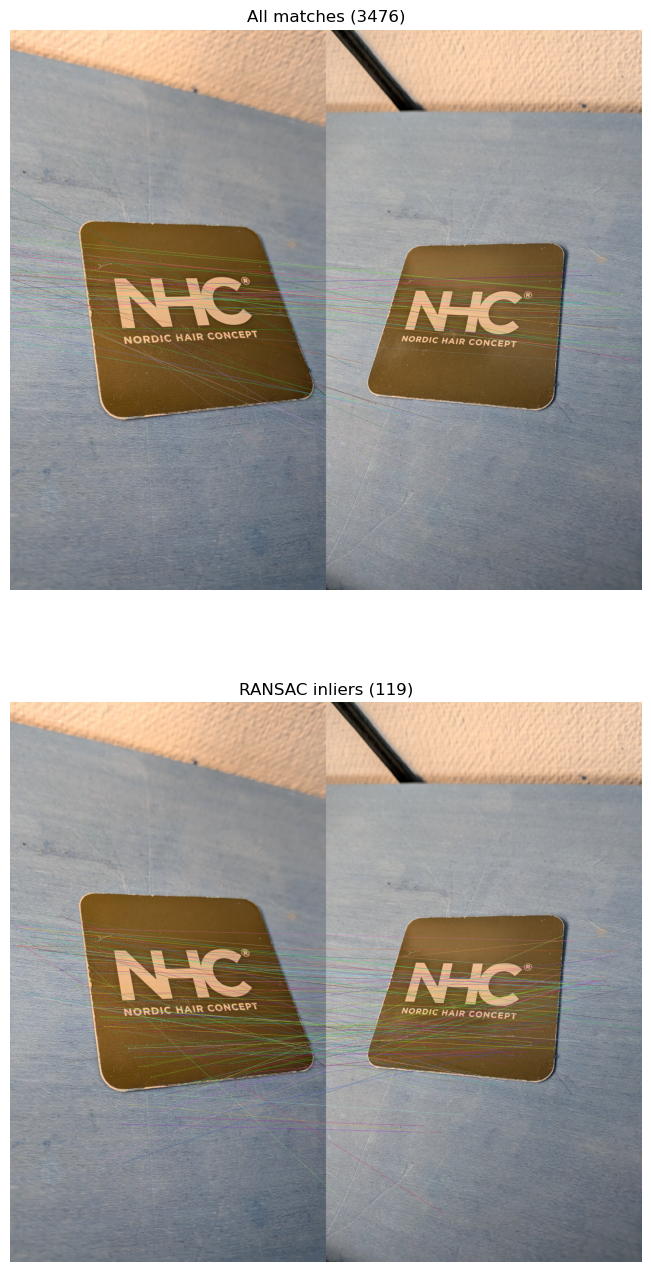

119 / 3476 matches kept (3%)


In [24]:
def Fest_RANSAC(kp1, kp2, matches, threshold=3.84*3**2, iters=200):
    matches_arr = np.array(matches, dtype=object)
    p1_all = np.array([kp1[m.queryIdx].pt for m in matches_arr]).T  # (2,n)
    p2_all = np.array([kp2[m.trainIdx].pt for m in matches_arr]).T  # (2,n)

    best_inliers = None
    best_count = -1

    for _ in range(iters):
        sample = np.random.choice(matches_arr, 8, replace=False)
        p1_sample = np.array([kp1[m.queryIdx].pt for m in sample]).T
        p2_sample = np.array([kp2[m.trainIdx].pt for m in sample]).T

        F = Fest_8point(p1_sample, p2_sample)
        dist = SampsonsDistance(F, p1_all, p2_all)
        inliers = dist < threshold

        if inliers.sum() > best_count:
            best_count = inliers.sum()
            best_inliers = inliers

    F_final = Fest_8point(p1_all[:, best_inliers], p2_all[:, best_inliers])
    return F_final, best_inliers

im1 = cv2.imread('nhc1.jpg')
im2 = cv2.imread('nhc2.jpg')

sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(im1, None)
kp2, des2 = sift.detectAndCompute(im2, None)

bf = cv2.BFMatcher_create(crossCheck=True)
matches = bf.match(des1, des2)

F, inliers = Fest_RANSAC(kp1, kp2, matches)

matches_arr = np.array(matches, dtype=object)
matches_in = list(matches_arr[inliers])
matches_out = list(matches_arr[~inliers])

fig, ax = plt.subplots(2, 1, figsize=(16, 16))
img_all = cv2.drawMatches(im1, kp1, im2, kp2, matches[:50], None,
                           flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
img_in = cv2.drawMatches(im1, kp1, im2, kp2, matches_in, None,
                          flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
ax[0].imshow(img_all); ax[0].set_title(f'All matches ({len(matches)})'); ax[0].axis('off')
ax[1].imshow(img_in); ax[1].set_title(f'RANSAC inliers ({inliers.sum()})'); ax[1].axis('off')
plt.show()

print(f'{inliers.sum()} / {len(matches)} matches kept ({100*inliers.mean():.0f}%)')